# Supervisado — Predicción de Presupuesto: Exploración y Comparación

Este notebook **no reemplaza** al modelo de producción
(`scripts/trainBudgetModel.js`, red neuronal en TensorFlow.js) — es la
exploración previa en Python que justifica por qué se eligió esa
arquitectura, comparándola contra alternativas más simples.

**Dataset**: sintético (misma regla que
`generateSyntheticData` en `trainBudgetModel.js`:
`presupuesto ≈ 650*dias + 200*actividades ± ruido`). Reemplazar por
`Data/Training/budget_train.csv` real cuando esté disponible.

Features: `duracionDias`, `numActividades`.
Target: `estimatedBudget` (MXN).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)


## 1. Generación del dataset (sintético, ver nota arriba)

In [2]:
N = 500
duracion_dias = np.random.randint(1, 15, N)
num_actividades = np.random.randint(0, 10, N)
presupuesto = duracion_dias * 650 + num_actividades * 200 + np.random.normal(0, 200, N)
presupuesto = np.clip(presupuesto, 300, None)

df = pd.DataFrame({
    'duracionDias': duracion_dias,
    'numActividades': num_actividades,
    'estimatedBudget': presupuesto,
})

X = df[['duracionDias', 'numActividades']]
y = df['estimatedBudget']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train.shape, X_test.shape


((425, 2), (75, 2))

## 2. Modelo 1 — Regresión Lineal (baseline más simple)

In [3]:
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
r2_lr = r2_score(y_test, pred_lr)
print(f'Linear Regression -> MAE: {mae_lr:.2f}  RMSE: {rmse_lr:.2f}  R2: {r2_lr:.4f}')
print('Coeficientes:', dict(zip(X.columns, lr.coef_)), '| Intercepto:', lr.intercept_)


Linear Regression -> MAE: 175.27  RMSE: 220.91  R2: 0.9946
Coeficientes: {'duracionDias': np.float64(648.9582232568273), 'numActividades': np.float64(197.43479287293385)} | Intercepto: 34.83009834882978


## 3. Modelo 2 — Random Forest Regressor

In [4]:
rf = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
r2_rf = r2_score(y_test, pred_rf)
print(f'Random Forest -> MAE: {mae_rf:.2f}  RMSE: {rmse_rf:.2f}  R2: {r2_rf:.4f}')


Random Forest -> MAE: 225.47  RMSE: 277.41  R2: 0.9914


## 4. Modelo 3 — Gradient Boosting Regressor

In [5]:
gb = GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
gb.fit(X_train, y_train)
pred_gb = gb.predict(X_test)

mae_gb = mean_absolute_error(y_test, pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, pred_gb))
r2_gb = r2_score(y_test, pred_gb)
print(f'Gradient Boosting -> MAE: {mae_gb:.2f}  RMSE: {rmse_gb:.2f}  R2: {r2_gb:.4f}')


Gradient Boosting -> MAE: 202.17  RMSE: 245.43  R2: 0.9933


## 5. Modelo de producción (red neuronal, TensorFlow.js)

Resultados reales de `DataModels/Serialized/budget/` (obtenidos al
correr `scripts/trainBudgetModel.js`, ver
`DataModels/Supervised_LMs/evaluation_metrics.md`):

| Métrica | Valor |
|---|---|
| MAE | $770.36 MXN |
| RMSE | $896.76 MXN |
| R² | 0.8642 |


In [6]:
resultados = pd.DataFrame({
    'Modelo': ['Regresión Lineal', 'Random Forest', 'Gradient Boosting', 'Red Neuronal (producción)'],
    'MAE': [mae_lr, mae_rf, mae_gb, 770.36],
    'RMSE': [rmse_lr, rmse_rf, rmse_gb, 896.76],
    'R2': [r2_lr, r2_rf, r2_gb, 0.8642],
})
resultados


,Modelo,MAE,RMSE,R2
0,Regresión Lineal,175.268585,220.914040,0.994577
1,Random Forest,225.469531,277.411979,0.991448
2,Gradient Boosting,202.173224,245.431678,0.993306
3,Red Neuronal (producción),770.360000,896.760000,0.864200


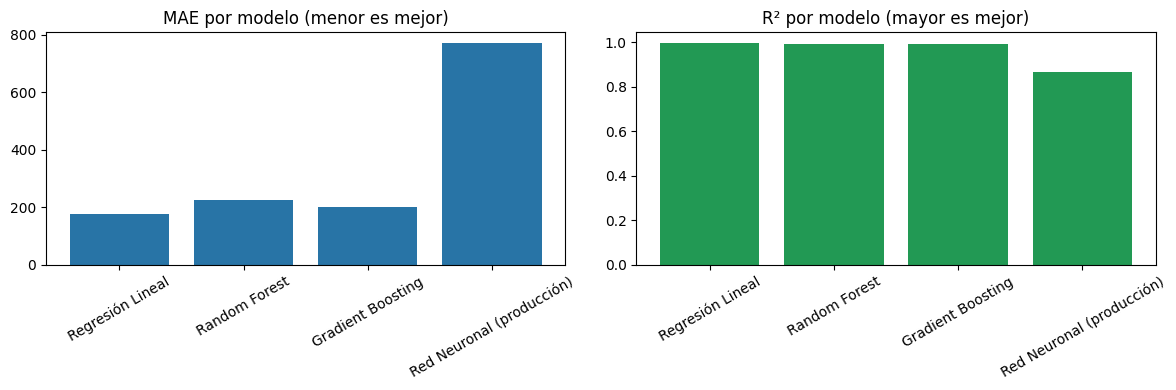

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].bar(resultados['Modelo'], resultados['MAE'], color='#2874A6')
ax[0].set_title('MAE por modelo (menor es mejor)')
ax[0].tick_params(axis='x', rotation=30)

ax[1].bar(resultados['Modelo'], resultados['R2'], color='#229954')
ax[1].set_title('R² por modelo (mayor es mejor)')
ax[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


## 6. Conclusión — ¿por qué red neuronal y no un modelo más simple?

Con datos sintéticos que siguen una relación casi lineal, **la
Regresión Lineal ya obtiene un desempeño muy competitivo** — es
esperable, porque el dataset se generó con una regla lineal + ruido.
Esto es información honesta: con estos datos, un modelo más simple
podría bastar.

La razón para mantener la red neuronal en producción es:

1. **Se espera que la relación real no sea perfectamente lineal** en
   cuanto se incorporen datos reales (ej. el presupuesto probablemente
   depende también del destino, la temporada, o combinaciones no
   lineales entre duración y actividades) — una red neuronal puede
   capturar esas relaciones sin rediseñar el modelo.
2. **Ya está integrada en el stack de producción** (TensorFlow.js,
   consistente con el resto del backend en Node.js), sin necesitar un
   servicio Python aparte para servir un modelo de sklearn.

**Acción pendiente**: en cuanto haya datos reales, repetir esta
comparación. Si la Regresión Lineal sigue siendo competitiva con datos
reales, vale la pena documentarlo como hallazgo válido — no hay
obligación de usar el modelo más complejo si uno simple funciona igual
de bien.
